# SBI Diagnostics

Diagnostics for Battaglia SBI datasets with one or more seed/lightcone realizations and optional SBI training outputs. Update the paths in the configuration cell if your cluster output directory differs.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})
import torch

In [2]:
import os
print (os.getcwd())

/home/cbllover/HalfDome/SBI_analysis


## Configuration

In [3]:
# Preferred cluster outputs from the SBI dataset combine scripts.

Ndata = 4096
dataset_seeds = "y100"
DATASET_PATH = Path(f"/lustre/work/kristero10/tSZ_data/sbi_battaglia_{dataset_seeds}_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz")
METADATA_PATH = DATASET_PATH.with_name(f"sbi_battaglia_{dataset_seeds}_{Ndata}_metadata.csv")
MANIFEST_PATH = DATASET_PATH.with_name(f"sbi_battaglia_{dataset_seeds}_{Ndata}_manifest.json")

# Optional SBI training output directory. Change this after running train_sbi.py.
SBI_OUTPUT_DIR = Path(f"outputs/posteriors")
NOTEBOOK_SBI_OUTPUT_DIR = SBI_OUTPUT_DIR / "notebook_training"
SAVE_NOTEBOOK_TRAINING_OUTPUTS = True

# Local fallbacks are useful when this notebook is run from SBI_analysis on the workstation copy.
LOCAL_FALLBACKS = [
    Path(f"../HPC_output/HalfDome/ydata_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz"),
    Path(f"../HPC_output/HalfDome/ydata_{Ndata}/sbi_battaglia_{dataset_seeds}_{Ndata}.npz"),
    Path(f"../HPC_output/HalfDome/Emulator/y100_y102_N256_trials1500/combined_battaglia_profiles.npz"),
]

if not DATASET_PATH.exists():
    DATASET_PATH = next((p for p in LOCAL_FALLBACKS if p.exists()), DATASET_PATH)
    METADATA_PATH = DATASET_PATH.with_name(DATASET_PATH.stem + "_metadata.csv")
    MANIFEST_PATH = DATASET_PATH.with_name(DATASET_PATH.stem + "_manifest.json")

EXPECTED_POINTS = Ndata
ELL_MIN = 2
ELL_MAX = 4096
SAVE_FIGURES = False
FIGURE_DIR = Path("diagnostic_figures")

print(f"Dataset:  {DATASET_PATH}")
print(f"Metadata: {METADATA_PATH if METADATA_PATH.exists() else '<not found>'}")
print(f"Manifest: {MANIFEST_PATH if MANIFEST_PATH.exists() else '<not found>'}")
print(f"SBI dir:  {SBI_OUTPUT_DIR}")
print(f"Notebook training dir: {NOTEBOOK_SBI_OUTPUT_DIR}")

Dataset:  ../HPC_output/HalfDome/ydata_4096/sbi_battaglia_y100_4096.npz
Metadata: ../HPC_output/HalfDome/ydata_4096/sbi_battaglia_y100_4096_metadata.csv
Manifest: ../HPC_output/HalfDome/ydata_4096/sbi_battaglia_y100_4096_manifest.json
SBI dir:  outputs/posteriors
Notebook training dir: outputs/posteriors/notebook_training


## Load Dataset

In [4]:
def as_str_list(values):
    return [str(v) for v in np.asarray(values).tolist()]


def seed_sort_key(name):
    label = name[3:] if name.startswith("cl_") else name
    if label.startswith("y") and label[1:].isdigit():
        return (0, int(label[1:]))
    return (1, label)


def seed_label_from_key(key):
    return key[3:] if key.startswith("cl_") else key


def mean_seed_spectra(seed_spectra):
    if not seed_spectra:
        return None
    shapes = {values.shape for values in seed_spectra.values()}
    if len(shapes) != 1:
        raise ValueError(f"Seed spectra have inconsistent shapes: {shapes}")
    if len(seed_spectra) == 1:
        return next(iter(seed_spectra.values()))
    return np.mean(np.stack(list(seed_spectra.values()), axis=0), axis=0)


def load_battaglia_dataset(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(path)

    with np.load(path, allow_pickle=True) as data:
        keys = set(data.files)
        ell = np.asarray(data["ell"], dtype=float).reshape(-1)
        mask = ell >= ELL_MIN
        if ELL_MAX is not None:
            mask &= ell <= ELL_MAX

        if {"theta", "ell", "theta_columns"}.issubset(keys):
            schema = "combine_sbi_dataset"
            theta = np.asarray(data["theta"], dtype=float)
            columns = as_str_list(data["theta_columns"])
            seed_keys = sorted((key for key in keys if key.startswith("cl_y")), key=seed_sort_key)
            seed_spectra = {
                seed_label_from_key(key): np.asarray(data[key], dtype=float)[:, mask]
                for key in seed_keys
            }

            if seed_spectra:
                cl_mean = mean_seed_spectra(seed_spectra)
            elif "cl_stack" in keys:
                cl_stack = np.asarray(data["cl_stack"], dtype=float)
                if cl_stack.ndim != 3:
                    raise ValueError(f"Expected cl_stack with shape (n, n_seeds, ell), got {cl_stack.shape}")
                if "seed_ids" in keys:
                    seed_labels = [f"y{int(seed)}" for seed in np.asarray(data["seed_ids"]).reshape(-1)]
                else:
                    seed_labels = [f"seed_{idx}" for idx in range(cl_stack.shape[1])]
                if len(seed_labels) != cl_stack.shape[1]:
                    raise ValueError(f"seed_ids length {len(seed_labels)} does not match cl_stack seed axis {cl_stack.shape[1]}")
                seed_spectra = {
                    label: cl_stack[:, idx, :][:, mask]
                    for idx, label in enumerate(seed_labels)
                }
                cl_mean = mean_seed_spectra(seed_spectra)
            elif "cl_mean" in keys:
                cl_mean = np.asarray(data["cl_mean"], dtype=float)[:, mask]
                seed_spectra = {}
            else:
                raise KeyError(f"{path} has no C_l arrays matching cl_y*, cl_stack, or cl_mean")
        elif {"x", "ell", "x_columns"}.issubset(keys):
            schema = "build_battaglia_emulator"
            theta = np.asarray(data["x"], dtype=float)
            columns = as_str_list(data["x_columns"])
            seed_keys = sorted(
                (key for key in keys if key.startswith("y") and key[1:].isdigit()),
                key=seed_sort_key,
            )
            seed_spectra = {
                key: np.asarray(data[key], dtype=float)[:, mask]
                for key in seed_keys
            }
            if seed_spectra:
                cl_mean = mean_seed_spectra(seed_spectra)
            elif "y_combined" in keys:
                cl_mean = np.asarray(data["y_combined"], dtype=float)[:, mask]
            else:
                raise KeyError(f"{path} has no seed arrays matching y<seed> or y_combined")
        else:
            raise KeyError(f"Unsupported dataset schema. Keys: {sorted(keys)}")

    if theta.shape[0] != cl_mean.shape[0]:
        raise ValueError(f"theta rows {theta.shape[0]} and cl_mean rows {cl_mean.shape[0]} do not match")

    dataset = {
        "path": path,
        "schema": schema,
        "keys": sorted(keys),
        "theta": theta,
        "columns": columns,
        "ell": ell[mask],
        "cl_mean": cl_mean,
        "seed_names": list(seed_spectra),
        "seed_spectra": seed_spectra,
    }
    for name, values in seed_spectra.items():
        dataset[f"cl_{name}"] = values
    return dataset


dataset = load_battaglia_dataset(DATASET_PATH)
theta = dataset["theta"]
ell = dataset["ell"]
cl_mean = dataset["cl_mean"]
seed_names = dataset["seed_names"]
seed_spectra = dataset["seed_spectra"]
cl_y100 = seed_spectra.get("y100")
cl_y102 = seed_spectra.get("y102")
columns = dataset["columns"]

print("Schema:", dataset["schema"])
print("Keys:", dataset["keys"])
print("theta:", theta.shape)
print("cl_mean:", cl_mean.shape)
print("seeds:", seed_names if seed_names else "<none>")
for seed_name, values in seed_spectra.items():
    print(f"cl_{seed_name}:", values.shape)
print("ell range:", float(ell.min()), float(ell.max()), "n_ell=", ell.size)
print("columns:", columns)

Schema: combine_sbi_dataset
Keys: ['cl_concat', 'cl_log10_concat', 'cl_log10_mean', 'cl_log10_y100', 'cl_mean', 'cl_stack', 'cl_y100', 'ell', 'param_key', 'seed_ids', 'sobol_global_row', 'sobol_row', 'sobol_split', 'target_floor', 'theta', 'theta_columns']
theta: (4096, 9)
cl_mean: (4096, 4095)
seeds: ['y100']
cl_y100: (4096, 4095)
ell range: 2.0 4096.0 n_ell= 4095
columns: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']


## Basic Integrity Checks

In [5]:
def count_nonfinite(name, values):
    n_bad = int((~np.isfinite(values)).sum())
    print(f"{name:10s} non-finite: {n_bad}")
    return n_bad


print(f"Expected points: {EXPECTED_POINTS}")
print(f"Actual points:   {theta.shape[0]}")
if theta.shape[0] != EXPECTED_POINTS:
    print("WARNING: dataset point count does not match EXPECTED_POINTS")

count_nonfinite("theta", theta)
count_nonfinite("cl_mean", cl_mean)
for seed_name, values in seed_spectra.items():
    count_nonfinite(f"cl_{seed_name}", values)

arrays_to_summarize = [("cl_mean", cl_mean)] + [(f"cl_{seed_name}", values) for seed_name, values in seed_spectra.items()]
for name, values in arrays_to_summarize:
    finite = values[np.isfinite(values)]
    print(
        f"{name:10s} min={finite.min():.4e} median={np.median(finite):.4e} "
        f"max={finite.max():.4e} max_abs={np.max(np.abs(finite)):.4e}"
    )

if seed_spectra:
    seed_average = mean_seed_spectra(seed_spectra)
    print(
        f"mean equals average of {len(seed_spectra)} loaded seed(s):",
        np.allclose(cl_mean, seed_average, rtol=1e-7, atol=0.0),
    )
else:
    print("No individual seed spectra were loaded; cl_mean was read directly.")

Expected points: 4096
Actual points:   4096
theta      non-finite: 0
cl_mean    non-finite: 0
cl_y100    non-finite: 0
cl_mean    min=8.6401e-24 median=1.2727e-18 max=1.1880e-12 max_abs=1.1880e-12
cl_y100    min=8.6401e-24 median=1.2727e-18 max=1.1880e-12 max_abs=1.1880e-12
mean equals average of 1 loaded seed(s): True


## Metadata And Split Coverage

In [6]:
metadata = None
manifest = None

if METADATA_PATH.exists():
    metadata = pd.read_csv(METADATA_PATH)
    display(metadata.head())
    print("metadata rows:", len(metadata))
    for col in ["sobol_split", "sobol_row", "sobol_global_row", "y100_n", "y102_n", "param_key"]:
        if col in metadata.columns:
            print(f"{col}: present")
    if "sobol_split" in metadata.columns:
        display(metadata["sobol_split"].value_counts().sort_index().rename("rows_per_split").to_frame())
    if "sobol_global_row" in metadata.columns:
        duplicates = metadata[metadata["sobol_global_row"].duplicated(keep=False)]
        print("duplicate sobol_global_row rows:", len(duplicates))
        expected = set(range(1, EXPECTED_POINTS + 1))
        actual = set(metadata["sobol_global_row"].astype(int))
        missing = sorted(expected - actual)
        extra = sorted(actual - expected)
        print("missing global rows:", missing[:20], "count=", len(missing))
        print("extra global rows:", extra[:20], "count=", len(extra))
    if {"y100_n", "y102_n"}.issubset(metadata.columns):
        display(metadata[["y100_n", "y102_n"]].value_counts().rename("count").to_frame())
else:
    print("Metadata CSV not found; skipping metadata checks.")

if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    print(json.dumps(manifest, indent=2)[:3000])
else:
    print("Manifest JSON not found; skipping manifest display.")

,sobol_global_row,sobol_split,param_key,y100_n,y100_files,sobol_csv,sobol_row,P0,xc,beta,alpha_m_P0,alpha_m_xc,alpha_m_beta,alpha_z_P0,alpha_z_xc,alpha_z_beta
0,1,1,15.8529402747|0.715737235136|4.88315821404|0.0...,1,/lustre/work/kristero10/tSZ_data/y100/halfdome...,/misc/home/kristero10/tSZ_data/battaglia_sobol...,1,15.852940,0.715737,4.883158,0.015641,-0.040412,0.080785,-0.571029,0.852594,0.618336
1,2,1,28.3673481793|0.282367160096|3.8704419611|0.26...,1,/lustre/work/kristero10/tSZ_data/y100/halfdome...,/misc/home/kristero10/tSZ_data/battaglia_sobol...,2,28.367348,0.282367,3.870442,0.268822,0.041469,-0.007490,-0.944246,0.279243,0.151430
2,3,1,19.0198215543|0.607358799539|4.65100724738|0.0...,1,/lustre/work/kristero10/tSZ_data/y100/halfdome...,/misc/home/kristero10/tSZ_data/battaglia_sobol...,3,19.019822,0.607359,4.651007,0.084153,0.085397,0.013521,-0.272949,0.465544,0.387519
3,4,1,9.15983847011|0.349977206245|4.10046890432|0.2...,1,/lustre/work/kristero10/tSZ_data/y100/halfdome...,/misc/home/kristero10/tSZ_data/battaglia_sobol...,4,9.159838,0.349977,4.100469,0.200292,-0.084280,0.044778,-1.251031,1.034361,0.501599
4,5,1,5.54230968719|0.531859592064|3.65426839488|0.1...,1,/lustre/work/kristero10/tSZ_data/y100/halfdome...,/misc/home/kristero10/tSZ_data/battaglia_sobol...,5,5.542310,0.531860,3.654268,0.153508,-0.072487,0.085710,-0.439909,0.657120,0.311437


metadata rows: 4096
sobol_split: present
sobol_row: present
sobol_global_row: present
y100_n: present
param_key: present


,rows_per_split
sobol_split,
1,128
2,128
3,128
4,128
5,128
6,128
7,128
8,128
9,128


duplicate sobol_global_row rows: 0
missing global rows: [] count= 0
extra global rows: [] count= 0
{
  "arrays": {
    "cl_concat": "Compatibility alias for cl_y100, shape (n_points, n_ell)",
    "cl_log10_*": "log10(max(raw, target_floor)) versions of the same targets",
    "cl_mean": "Compatibility alias for cl_y100, shape (n_points, n_ell)",
    "cl_stack": "Seed axis kept separate, shape (n_points, 1, n_ell)",
    "cl_y100": "Seed/lightcone 100 C_l/profile arrays, shape (n_points, n_ell)",
    "theta": "Battaglia parameter matrix, shape (n_points, n_parameters)"
  },
  "dataset_npz": "/lustre/work/kristero10/tSZ_data/sbi_battaglia_y100_4096/sbi_battaglia_y100_4096.npz",
  "ell_max": 4096,
  "ell_min": 2,
  "expected_points": 4096,
  "metadata_csv": "/lustre/work/kristero10/tSZ_data/sbi_battaglia_y100_4096/sbi_battaglia_y100_4096_metadata.csv",
  "n_ell": 4095,
  "n_parameter_points": 4096,
  "n_parameters": 9,
  "realizations": [
    "y100"
  ],
  "target_floor": 1e-40,
  "theta_co

## Parameter Coverage

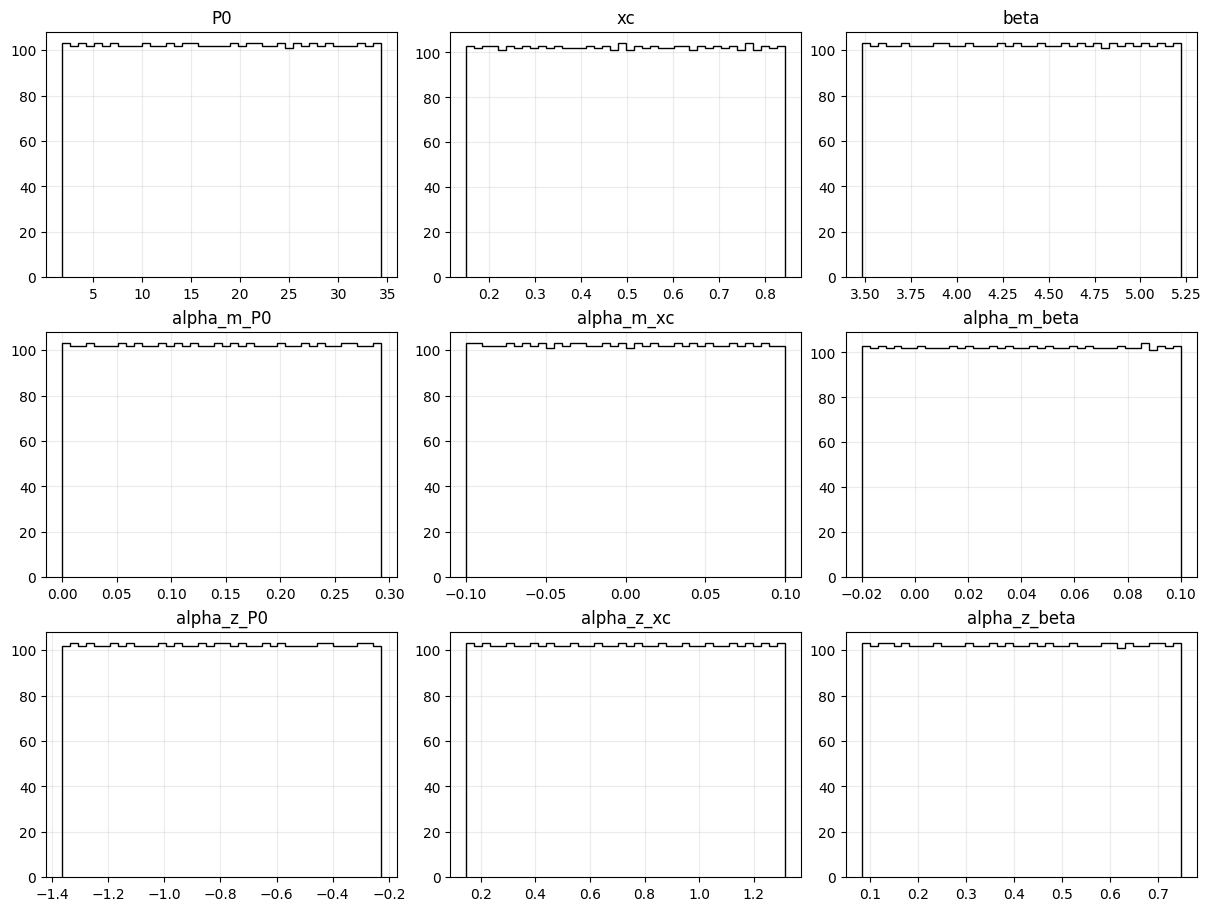

In [7]:
ncols = 3
nrows = math.ceil(len(columns) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)
for idx, name in enumerate(columns):
    axes[idx].hist(theta[:, idx], bins=40, histtype="step", color="black")
    axes[idx].set_title(name)
for ax in axes[len(columns):]:
    ax.axis("off")
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / "parameter_coverage.png", dpi=180)
plt.show()

In [8]:
param_summary = pd.DataFrame(theta, columns=columns).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(param_summary)

,count,mean,std,min,1%,5%,50%,95%,99%,max
P0,4096.0,1.810000e+01,9.406184,1.816402,2.138113,3.443574,18.102069,32.758308,34.058465,34.387662
xc,4096.0,4.970000e-01,0.200885,0.149226,0.156180,0.183981,0.496923,0.810045,0.837892,0.844852
beta,4096.0,4.350000e+00,0.502356,3.480174,3.497791,3.567162,4.350154,5.132677,5.202465,5.219653
alpha_m_P0,4096.0,1.463000e-01,0.084477,0.000008,0.002986,0.014654,0.146288,0.277912,0.289647,0.292554
alpha_m_xc,4096.0,-9.313226e-11,0.057742,-0.099971,-0.097966,-0.089997,-0.000011,0.089970,0.097993,0.099999
alpha_m_beta,4096.0,4.000000e-02,0.034645,-0.019986,-0.018781,-0.013985,0.040001,0.093983,0.098785,0.099990
alpha_z_P0,4096.0,-7.959000e-01,0.328264,-1.364399,-1.352840,-1.307519,-0.795896,-0.284290,-0.238969,-0.227409
alpha_z_xc,4096.0,7.310000e-01,0.337676,0.146317,0.157914,0.204770,0.730933,1.257095,1.303951,1.315548
alpha_z_beta,4096.0,4.150000e-01,0.191704,0.083152,0.089724,0.116347,0.415002,0.713658,0.740261,0.746853


## Spectrum Coverage

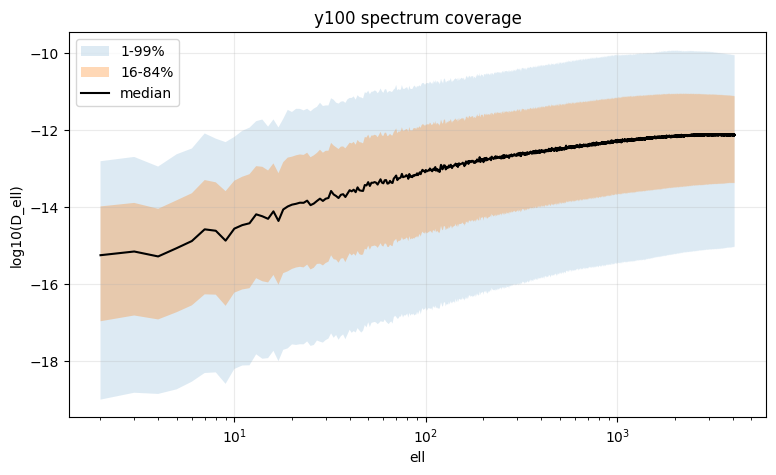

In [9]:
def cl_to_log10_dl(cl, ell, floor=1.0e-40):
    factor = ell * (ell + 1.0) / (2.0 * np.pi)
    return np.log10(np.maximum(np.asarray(cl) * factor, floor))


x_mean = cl_to_log10_dl(cl_mean, ell)
x_by_seed = {seed_name: cl_to_log10_dl(values, ell) for seed_name, values in seed_spectra.items()}
x_y100 = x_by_seed.get("y100")
x_y102 = x_by_seed.get("y102")
if len(seed_names) == 1:
    spectrum_label = seed_names[0]
elif seed_names:
    spectrum_label = f"mean of {len(seed_names)} seeds"
else:
    spectrum_label = "cl_mean"

q16, q50, q84 = np.percentile(x_mean, [16, 50, 84], axis=0)
q01, q99 = np.percentile(x_mean, [1, 99], axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(ell, q01, q99, alpha=0.15, label="1-99%")
ax.fill_between(ell, q16, q84, alpha=0.30, label="16-84%")
ax.plot(ell, q50, color="black", lw=1.5, label="median")
ax.set_xscale("log")
ax.set_xlabel("ell")
ax.set_ylabel("log10(D_ell)")
ax.set_title(f"{spectrum_label} spectrum coverage")
ax.legend()
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / "spectrum_coverage_log10_dl.png", dpi=180)
plt.show()

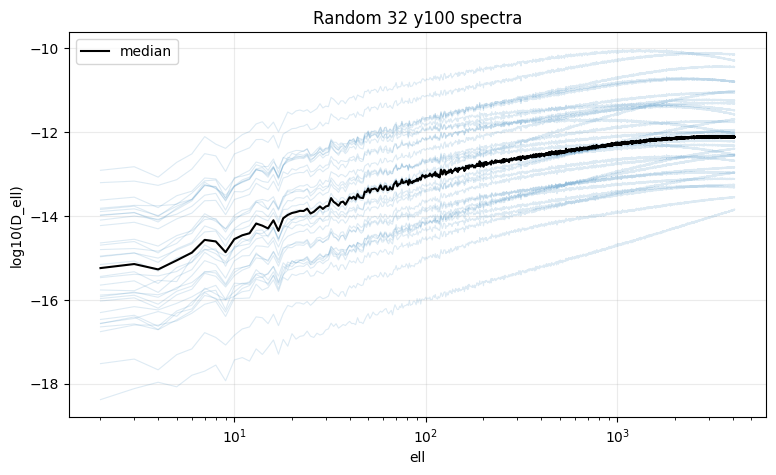

In [10]:
rng = np.random.default_rng(1234)
n_show = min(32, x_mean.shape[0])
chosen = rng.choice(x_mean.shape[0], size=n_show, replace=False)

fig, ax = plt.subplots(figsize=(9, 5))
for idx in chosen:
    ax.plot(ell, x_mean[idx], color="tab:blue", alpha=0.15, lw=0.8)
ax.plot(ell, q50, color="black", lw=1.5, label="median")
ax.set_xscale("log")
ax.set_xlabel("ell")
ax.set_ylabel("log10(D_ell)")
ax.set_title(f"Random {n_show} {spectrum_label} spectra")
ax.legend()
plt.show()

## Seed Scatter And Outliers

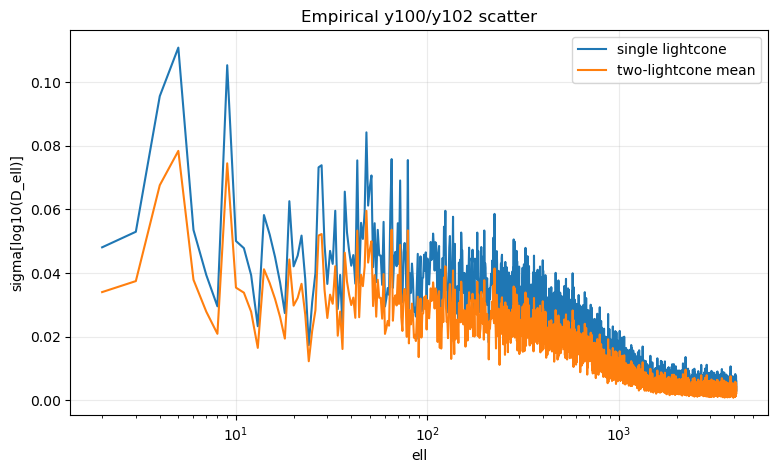

median sigma single: 0.005705519478047346
max sigma single: 0.11079167526209194


In [10]:
if len(x_by_seed) >= 2:
    x_seed_stack = np.stack(list(x_by_seed.values()), axis=0)
    seed_variance = np.nanvar(x_seed_stack, axis=0, ddof=1)
    sigma_single = np.sqrt(np.nanmean(seed_variance, axis=0))
    sigma_mean = sigma_single / np.sqrt(len(x_by_seed))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(ell, sigma_single, label="single seed")
    ax.plot(ell, sigma_mean, label=f"{len(x_by_seed)}-seed mean")
    ax.set_xscale("log")
    ax.set_xlabel("ell")
    ax.set_ylabel("sigma[log10(D_ell)]")
    ax.set_title("Empirical seed scatter")
    ax.legend()
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / "seed_scatter_log10_dl.png", dpi=180)
    plt.show()

    print("seed names:", seed_names)
    print("median sigma single:", float(np.nanmedian(sigma_single)))
    print("max sigma single:", float(np.nanmax(sigma_single)))
else:
    sigma_single = np.full_like(ell, np.nan, dtype=float)
    sigma_mean = np.full_like(ell, np.nan, dtype=float)
    print(f"Only {len(x_by_seed)} seed loaded; empirical seed scatter is not defined.")

In [11]:
rms_diff = np.sqrt(np.nanmean(diff**2, axis=1))
max_abs_diff = np.nanmax(np.abs(diff), axis=1)
outlier_table = pd.DataFrame({
    "row_index": np.arange(theta.shape[0]),
    "rms_log10_diff": rms_diff,
    "max_abs_log10_diff": max_abs_diff,
})
if metadata is not None:
    for col in ["sobol_global_row", "sobol_split", "sobol_row", "param_key"]:
        if col in metadata.columns:
            outlier_table[col] = metadata[col].to_numpy()
display(outlier_table.sort_values("rms_log10_diff", ascending=False).head(20))

,row_index,rms_log10_diff,max_abs_log10_diff,sobol_global_row,sobol_split,sobol_row,param_key
193,193,0.097532,0.991477,194,2,66,29.2710834808|0.150011494896|4.92838199213|0.1...
527,527,0.093252,0.874716,528,5,16,16.5015823226|0.156190472749|4.42988912825|0.2...
415,415,0.085130,0.930365,416,4,32,14.8993035027|0.209664200845|4.80993599821|0.2...
49,49,0.084869,0.852247,50,1,50,27.6706976984|0.178951896724|4.58156821171|0.2...
767,767,0.081537,1.001115,768,6,128,16.0023425967|0.171414289608|5.19815611755|0.1...
929,929,0.080573,0.927407,930,8,34,30.1399110831|0.231064302409|5.07371008152|0.2...
949,949,0.079047,0.833566,950,8,54,25.5816590186|0.162899731029|4.16957676139|0.1...
11,11,0.076619,0.887269,12,1,12,1.91400731791|0.253877612237|5.20612741683|0.2...
259,259,0.075660,0.952908,260,3,4,8.97400819931|0.172768884335|4.3717763594|0.25...
367,367,0.074654,0.954637,368,3,112,17.3589739013|0.227645100594|4.7077527993|0.08...


## Optional SBI Run Outputs

In [12]:
summary_path = SBI_OUTPUT_DIR / "sbi_run_summary.json"
config_path = SBI_OUTPUT_DIR / "run_config.json"

if summary_path.exists():
    summary = json.loads(summary_path.read_text())
    print(json.dumps(summary, indent=2))
else:
    print(f"No SBI summary found at {summary_path}")

if config_path.exists():
    run_config = json.loads(config_path.read_text())
    print("\nrun_config paths:")
    for key in ["combined_dataset_path", "emulator_artifact_path", "observed_spectrum_path", "output_dir"]:
        print(f"  {key}: {run_config.get(key)}")

No SBI summary found at \lustre\work\kristero10\tSZ_data\sbi_battaglia9_1024\sbi_run_summary.json


posterior samples: (40000, 9)


,count,mean,std,min,5%,16%,50%,84%,95%,max
P0,40000.0,17.943729,4.988765,2.577474,10.585952,13.120870,17.438396,22.857847,27.111511,34.339390
xc,40000.0,0.524160,0.098472,0.173237,0.366186,0.424864,0.521576,0.623454,0.691171,0.844243
beta,40000.0,4.427297,0.354872,3.481274,3.821305,4.061197,4.432684,4.799596,5.010514,5.216587
alpha_m_P0,40000.0,0.139206,0.062399,0.000351,0.035933,0.073390,0.138761,0.204806,0.244622,0.292244
alpha_m_xc,40000.0,-0.009801,0.035475,-0.099665,-0.069055,-0.046117,-0.009818,0.026238,0.049054,0.099785
alpha_m_beta,40000.0,0.044973,0.025742,-0.019888,0.001181,0.017906,0.045422,0.072086,0.087246,0.099765
alpha_z_P0,40000.0,-0.737172,0.228050,-1.362450,-1.124077,-0.973145,-0.732517,-0.499267,-0.363822,-0.228875
alpha_z_xc,40000.0,0.722344,0.187530,0.152092,0.420303,0.530523,0.717367,0.917159,1.037085,1.311420
alpha_z_beta,40000.0,0.422554,0.122252,0.083896,0.217520,0.298398,0.423659,0.546710,0.625591,0.745794


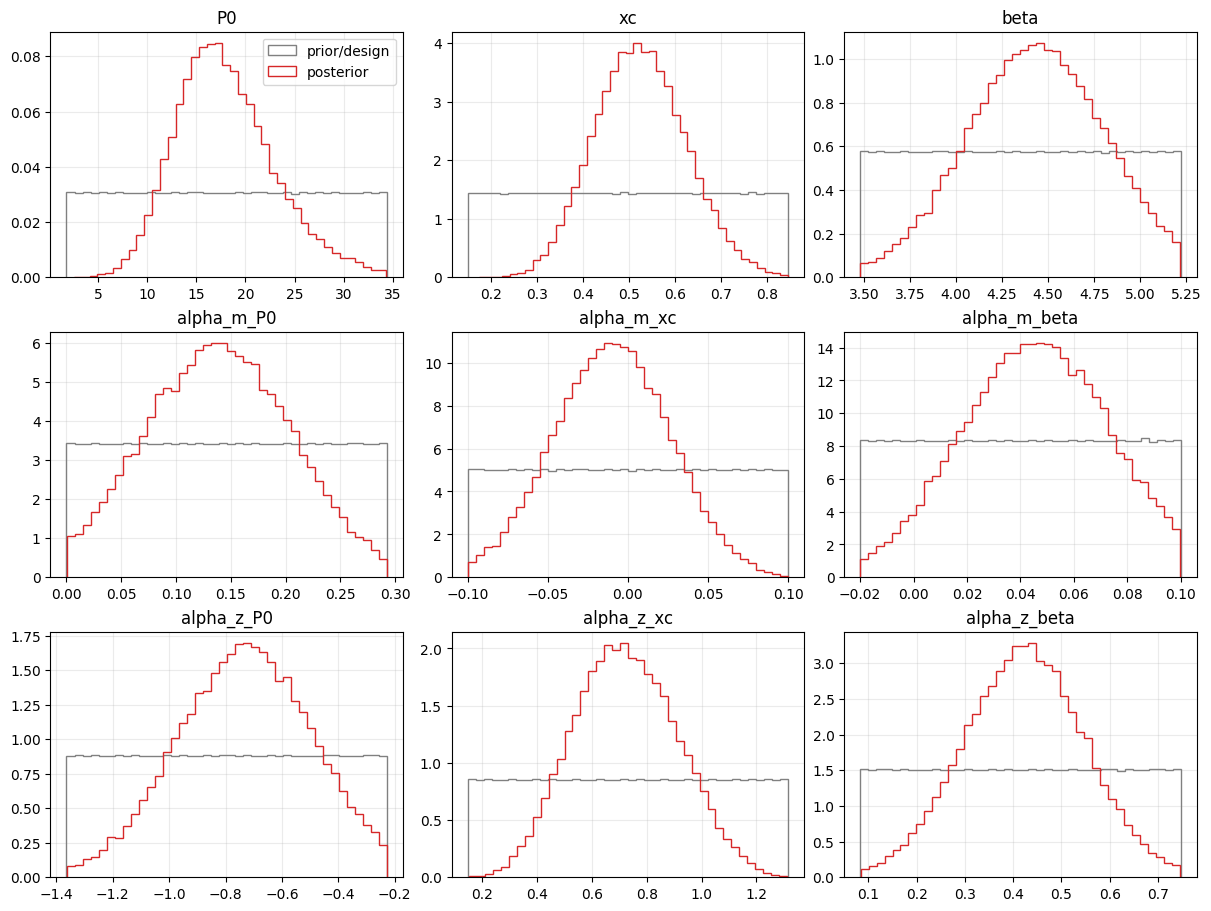

In [11]:
posterior_path = SBI_OUTPUT_DIR / "posterior_4096_sample_noisy.npy"
if posterior_path.exists():
    posterior_samples = np.load(posterior_path)
    print("posterior samples:", posterior_samples.shape)
    post_df = pd.DataFrame(posterior_samples, columns=columns[:posterior_samples.shape[1]])
    display(post_df.describe(percentiles=[0.05, 0.16, 0.5, 0.84, 0.95]).T)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0 * nrows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)
    for idx, name in enumerate(post_df.columns):
        axes[idx].hist(theta[:, idx], bins=40, density=True, histtype="step", color="0.5", label="prior/design")
        axes[idx].hist(post_df[name], bins=40, density=True, histtype="step", color="tab:red", label="posterior")
        axes[idx].set_title(name)
        if idx == 0:
            axes[idx].legend()
    for ax in axes[len(post_df.columns):]:
        ax.axis("off")
    if SAVE_FIGURES:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / "posterior_1d_vs_design.png", dpi=180)
    plt.show()
else:
    posterior_samples = None
    print(f"No posterior samples found at {posterior_path}")

## Optional Emulator Validation Residuals

In [14]:
validation_path = SBI_OUTPUT_DIR / "emulator_dataset_validation.npz"
if validation_path.exists():
    val = np.load(validation_path, allow_pickle=True)
    residual = np.asarray(val["residual"], dtype=float)
    val_ell = np.asarray(val["ell"], dtype=float)
    p16, p50, p84 = np.percentile(residual, [16, 50, 84], axis=0)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(val_ell, p16, p84, alpha=0.25, label="16-84%")
    ax.plot(val_ell, p50, color="black", lw=1.5, label="median")
    ax.axhline(0.0, color="tab:red", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("ell")
    ax.set_ylabel("emulator - dataset [log10(D_ell)]")
    ax.set_title("Emulator validation residuals")
    ax.legend()
    plt.show()

    print("median abs residual:", float(np.median(np.abs(residual))))
    print("p84 abs residual:", float(np.percentile(np.abs(residual), 84)))
    print("max abs residual:", float(np.max(np.abs(residual))))
else:
    print(f"No emulator validation file found at {validation_path}")

No emulator validation file found at outputs/posteriors/emulator_dataset_validation.npz


SBI diagnostic


In [12]:
from sbi.inference import NPE
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot

2026-06-04 16:56:27.994326: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 16:56:28.931918: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/kn18001/.conda/envs/class_sz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
def to_tensor(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().float()
    return torch.as_tensor(x, dtype=torch.float32)


def split_train_validation(prepared, n_train=850, n_val=174, seed=0):
    theta = to_tensor(prepared["theta"])
    x = to_tensor(prepared["x"])

    n_total = theta.shape[0]
    assert n_train + n_val <= n_total, "Not enough simulations."

    rng = torch.Generator().manual_seed(seed)
    indices = torch.randperm(n_total, generator=rng)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]

    return {
        "theta_train": theta[train_idx],
        "x_train": x[train_idx],
        "theta_val": theta[val_idx],
        "x_val": x[val_idx],
        "train_idx": train_idx,
        "val_idx": val_idx,
    }

In [14]:
from sbi_utils import cl_to_log10_dl, estimate_lightcone_sigma, prior_bounds, save_pickle, selected_ell_mask, write_json
from sbi.utils import BoxUniform
SOBOL_PRIOR_BOUNDS = {
    "P0": [1.832524, 34.341221],
    "xc": [0.150011, 0.844503],
    "beta": [3.480627, 5.216611],
    "alpha_m_P0": [0.000312, 0.292251],
    "alpha_m_xc": [-0.099718, 0.099795],
    "alpha_m_beta": [-0.019935, 0.099767],
    "alpha_z_P0": [-1.363457, -0.228839],
    "alpha_z_xc": [0.147393,1.314474],
    "alpha_z_beta": [0.083808, 0.745884],
}

prior_low_np, prior_high_np = prior_bounds({"prior": SOBOL_PRIOR_BOUNDS}, columns)

prior_low_cpu = torch.from_numpy(prior_low_np.astype(np.float32, copy=False))
prior_high_cpu = torch.from_numpy(prior_high_np.astype(np.float32, copy=False))


prior = BoxUniform(low=prior_low_cpu, high=prior_high_cpu)


In [15]:
param_summary.row

AttributeError: 'DataFrame' object has no attribute 'row'

In [20]:
prepared = {
    "theta": theta,
    "x": x_mean}

split = split_train_validation(
    prepared,
    n_train=850,
    n_val=174,
    seed=1,
)

inference = NPE(prior=prior)

density_estimator = inference.append_simulations(
    split["theta_train"],
    split["x_train"],
).train()

posterior = inference.build_posterior(density_estimator)

if SAVE_NOTEBOOK_TRAINING_OUTPUTS:
    NOTEBOOK_SBI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_prior.pkl", prior)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_inference.pkl", inference)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_density_estimator.pkl", density_estimator)
    save_pickle(NOTEBOOK_SBI_OUTPUT_DIR / "sbi_posterior.pkl", posterior)
    np.savez_compressed(
        NOTEBOOK_SBI_OUTPUT_DIR / "sbi_training_split.npz",
        train_idx=split["train_idx"].detach().cpu().numpy(),
        val_idx=split["val_idx"].detach().cpu().numpy(),
        theta_train=split["theta_train"].detach().cpu().numpy(),
        x_train=split["x_train"].detach().cpu().numpy(),
        theta_val=split["theta_val"].detach().cpu().numpy(),
        x_val=split["x_val"].detach().cpu().numpy(),
        ell=ell.astype(np.float32),
        columns=np.asarray(columns),
    )
    write_json(
        NOTEBOOK_SBI_OUTPUT_DIR / "sbi_training_summary.json",
        {
            "dataset_path": str(DATASET_PATH),
            "n_dataset_points": int(theta.shape[0]),
            "n_train": int(split["theta_train"].shape[0]),
            "n_val": int(split["theta_val"].shape[0]),
            "n_ell": int(ell.size),
            "ell_min": float(ell[0]),
            "ell_max": float(ell[-1]),
            "columns": list(columns),
            "seed_names": list(seed_names),
        },
    )
    print(f"Saved notebook SBI training artifacts to {NOTEBOOK_SBI_OUTPUT_DIR}")

 Neural network successfully converged after 195 epochs.

/home/cbllover/HalfDome/SBI_analysis/sbi_utils.py:368: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump(obj, handle, protocol=pickle.HIGHEST_PROTOCOL)


Saved notebook SBI training artifacts to outputs/posteriors/notebook_training


In [21]:
def sample_validation_posteriors(
    posterior,
    x_val,
    num_posterior_samples=1000,
):
    all_samples = []

    for i in range(x_val.shape[0]):
        samples_i = posterior.sample(
            (num_posterior_samples,),
            x=x_val[i],
            show_progress_bars=False,
        )
        all_samples.append(samples_i.detach().cpu())

    return torch.stack(all_samples, dim=0)

In [22]:
# validation_samples.shape = (n_val, num_posterior_samples, n_params)
validation_samples = sample_validation_posteriors(
    posterior,
    split["x_val"],
    num_posterior_samples=1000,
)

if SAVE_NOTEBOOK_TRAINING_OUTPUTS:
    NOTEBOOK_SBI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(validation_samples.cpu(), NOTEBOOK_SBI_OUTPUT_DIR / "validation_posterior_samples.pt")
    np.save(
        NOTEBOOK_SBI_OUTPUT_DIR / "validation_posterior_samples.npy",
        validation_samples.detach().cpu().numpy(),
    )
    print(f"Saved validation posterior samples to {NOTEBOOK_SBI_OUTPUT_DIR}")

Saved validation posterior samples to outputs/posteriors/notebook_training


# Parameter recovery diagnostics

In [23]:
def validation_parameter_recovery(
    posterior_samples,
    theta_true,
    prior_min,
    prior_max,
    labels=None,
):
    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)
    prior_delta = prior_max - prior_min

    n_val, n_post, n_params = samples.shape

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    mean = samples.mean(dim=1)
    median = samples.median(dim=1).values
    std = samples.std(dim=1)

    error = mean - theta_true
    abs_error = torch.abs(error)

    z_score = error / std
    frac_error = error / prior_delta
    abs_frac_error = abs_error / prior_delta

    rows = []

    for j, name in enumerate(labels):
        rows.append({
            "parameter": name,
            "mean_abs_error": abs_error[:, j].mean().item(),
            "mean_abs_error / prior_delta": abs_frac_error[:, j].mean().item(),
            "bias": error[:, j].mean().item(),
            "bias / prior_delta": frac_error[:, j].mean().item(),
            "mean_posterior_std": std[:, j].mean().item(),
            "mean_posterior_std / prior_delta": (std[:, j] / prior_delta[j]).mean().item(),
            "mean_abs_z_score": torch.abs(z_score[:, j]).mean().item(),
            "rms_z_score": torch.sqrt(torch.mean(z_score[:, j] ** 2)).item(),
        })

    return pd.DataFrame(rows)

In [24]:
recovery_df = validation_parameter_recovery(
    validation_samples,
    split["theta_val"],
    prior_low_cpu,
    prior_high_cpu,
    labels=columns,
)

recovery_df

,parameter,mean_abs_error,mean_abs_error / prior_delta,bias,bias / prior_delta,mean_posterior_std,mean_posterior_std / prior_delta,mean_abs_z_score,rms_z_score
0,P0,7.413277,0.228040,-1.426281,-0.043874,6.639248,0.204230,1.117527,1.308588
1,xc,0.094356,0.135863,0.019792,0.028498,0.100738,0.145053,0.944734,1.196593
2,beta,0.391064,0.225269,-0.021534,-0.012404,0.387814,0.223398,1.013279,1.212755
3,alpha_m_P0,0.066400,0.227444,0.011091,0.037991,0.063825,0.218626,1.034371,1.228426
4,alpha_m_xc,0.045004,0.225570,-0.005752,-0.028831,0.044158,0.221329,1.020855,1.170660
5,alpha_m_beta,0.025748,0.215100,-0.000116,-0.000969,0.026366,0.220266,0.977503,1.160700
6,alpha_z_P0,0.264455,0.233079,0.022543,0.019868,0.243635,0.214729,1.087714,1.295669
7,alpha_z_xc,0.209303,0.179339,0.005813,0.004981,0.184080,0.157727,1.124158,1.363438
8,alpha_z_beta,0.141108,0.213130,0.015499,0.023409,0.135550,0.204735,1.035529,1.212764


# NEEDS INTERPRETATION

# Coverege test per parameteter

In [25]:
def marginal_coverage(
    posterior_samples,
    theta_true,
    labels=None,
    levels=(0.50, 0.68, 0.90, 0.95),
):
    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    n_val, n_post, n_params = samples.shape

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    rows = []

    for level in levels:
        alpha = 1.0 - level
        q_low = alpha / 2
        q_high = 1.0 - alpha / 2

        lower = torch.quantile(samples, q_low, dim=1)
        upper = torch.quantile(samples, q_high, dim=1)

        inside = (theta_true >= lower) & (theta_true <= upper)

        for j, name in enumerate(labels):
            rows.append({
                "parameter": name,
                "nominal_coverage": level,
                "empirical_coverage": inside[:, j].float().mean().item(),
                "difference": inside[:, j].float().mean().item() - level,
            })

    return pd.DataFrame(rows)

In [26]:
coverage_df = marginal_coverage(
    validation_samples,
    split["theta_val"],
    labels=columns,
)

coverage_df

,parameter,nominal_coverage,empirical_coverage,difference
0,P0,0.50,0.327586,-0.172414
1,xc,0.50,0.442529,-0.057471
2,beta,0.50,0.413793,-0.086207
3,alpha_m_P0,0.50,0.373563,-0.126437
4,alpha_m_xc,0.50,0.390805,-0.109195
5,alpha_m_beta,0.50,0.425287,-0.074713
6,alpha_z_P0,0.50,0.367816,-0.132184
7,alpha_z_xc,0.50,0.339080,-0.160920
8,alpha_z_beta,0.50,0.350575,-0.149425
9,P0,0.68,0.459770,-0.220230


In [27]:
def plot_coverage(coverage_df):
    params = coverage_df["parameter"].unique()

    plt.figure(figsize=(7, 5))

    for p in params:
        d = coverage_df[coverage_df["parameter"] == p]
        plt.plot(
            d["nominal_coverage"],
            d["empirical_coverage"],
            marker="o",
            label=p,
        )

    x = np.linspace(0, 1, 100)
    plt.plot(x, x, color="black", ls="--", label="ideal")

    plt.xlabel("Nominal credible level")
    plt.ylabel("Empirical coverage")
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

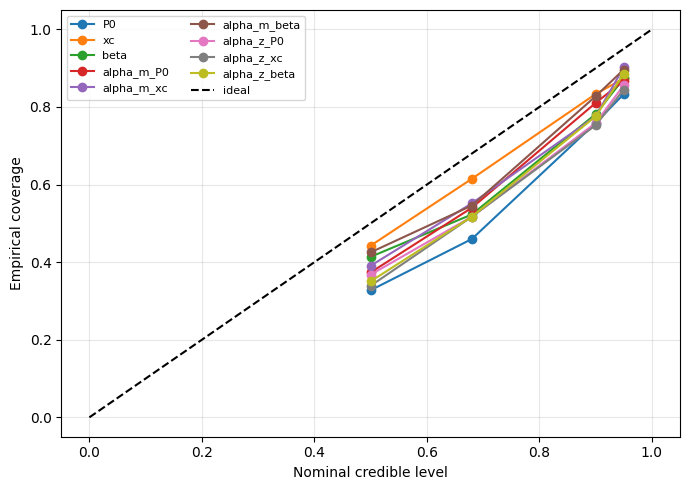

In [28]:
plot_coverage(coverage_df)

# SBC tests

Calculating ranks for 174 SBC samples: 100%|███████████████████████████████████████████| 174/174 [00:00<00:00, 4273.89it/s]


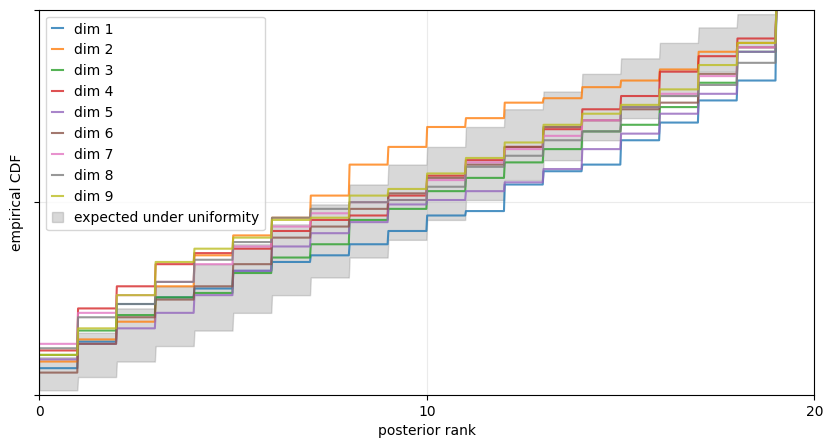

In [29]:
num_sbc_samples = min(200, split["theta_val"].shape[0])
num_posterior_samples = 1000

ranks, dap_samples = run_sbc(
    split["theta_val"][:num_sbc_samples],
    split["x_val"][:num_sbc_samples],
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
)

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 5),
)

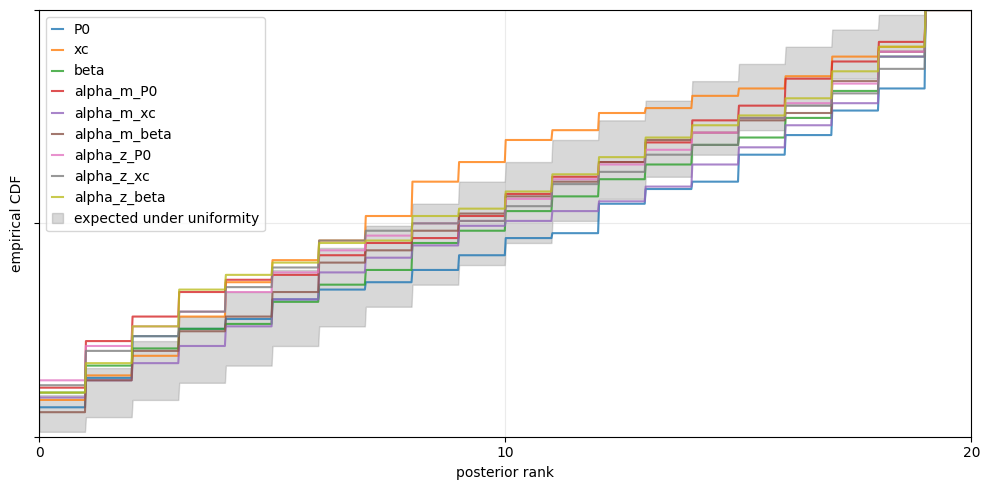

In [47]:
parameter_labels = [str(c) for c in columns[:ranks.shape[1]]]

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 5),
    parameter_labels=parameter_labels,
)

fig.tight_layout()
plt.savefig("../plots/SBI_plots/posterior_rank_plots_joint_4096.jpg")

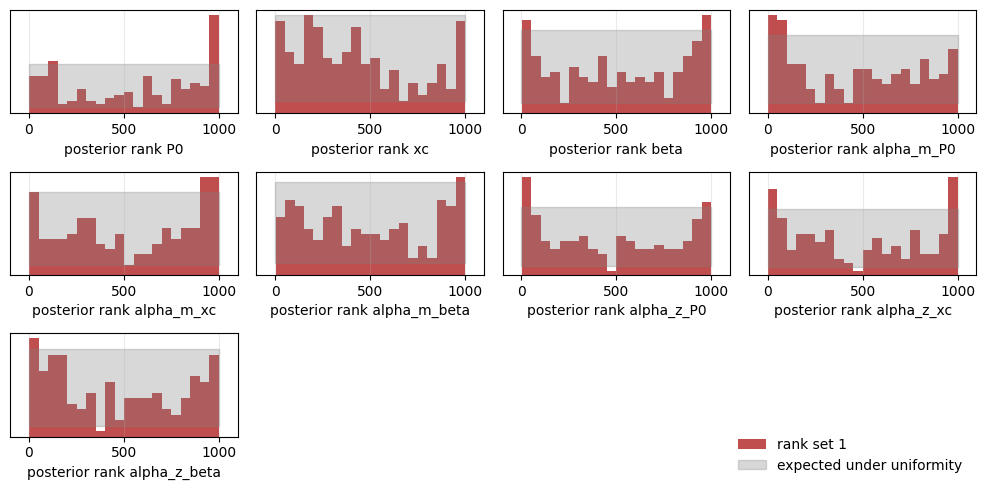

In [45]:
import numpy as np

fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(10, 5),
    plot_type="hist",
    parameter_labels=[str(c) for c in columns[:ranks.shape[1]]],
)

axes = np.asarray(ax).ravel()

# Get legend entries from one axis, or combine from all axes
handles, labels = axes[0].get_legend_handles_labels()

# Remove legends from individual subplots, if any exist
for a in axes:
    leg = a.get_legend()
    if leg is not None:
        leg.remove()

# One legend for the whole figure, bottom right
fig.legend(
    handles,
    labels,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    frameon=False,
)

fig.tight_layout()
plt.savefig("../plots/SBI_plots/posterior_rank_plots_seperate_4096.jpg")

In [40]:
columns

['P0',
 'xc',
 'beta',
 'alpha_m_P0',
 'alpha_m_xc',
 'alpha_m_beta',
 'alpha_z_P0',
 'alpha_z_xc',
 'alpha_z_beta']

In [30]:
checks = check_sbc(
    ranks,
    split["theta_val"][:num_sbc_samples],
    dap_samples,
    num_posterior_samples=num_posterior_samples,
)

checks

{'ks_pvals': tensor([0.0005, 0.0003, 0.0072, 0.0011, 0.0036, 0.0873, 0.0111, 0.0220, 0.0008]),
 'c2st_ranks': tensor([0.5920, 0.4885, 0.5313, 0.5056, 0.5087, 0.5516, 0.4655, 0.5344, 0.5659],
        dtype=torch.float64),
 'c2st_dap': tensor([0.4915, 0.4858, 0.4569, 0.5142, 0.5344, 0.5255, 0.5027, 0.4971, 0.5172],
        dtype=torch.float64)}

# Expected coverage / joint calibration

Calculating ranks for 174 SBC samples: 100%|█████████████████████████████████████████████| 174/174 [14:05<00:00,  4.86s/it]


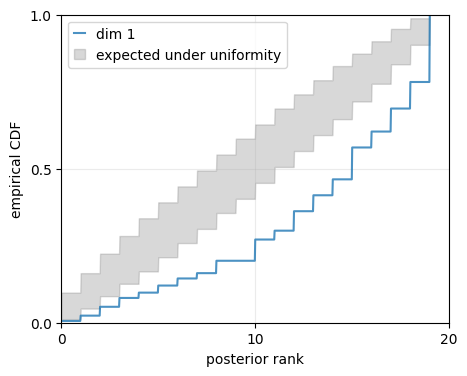

In [31]:
ranks_ec, dap_samples_ec = run_sbc(
    split["theta_val"][:num_sbc_samples],
    split["x_val"][:num_sbc_samples],
    posterior,
    reduce_fns=lambda theta, x: -posterior.log_prob(theta, x),
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,
)

fig, ax = sbc_rank_plot(
    ranks_ec,
    num_posterior_samples,
    plot_type="cdf",
    num_bins=20,
    figsize=(5, 4),
)

# Recovery scatter plot

In [55]:
def plot_recovery_scatter(
    posterior_samples,
    theta_true,
    labels=None,
    savefig_bool = False,
    savefig_name = ""
):
    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    mean = samples.mean(dim=1)

    n_params = theta_true.shape[1]

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    fig, axes = plt.subplots(
        1,
        n_params,
        figsize=(3.0 * n_params, 8),
        squeeze=False,
    )

    for j in range(n_params):
        ax = axes[0, j]

        x = theta_true[:, j].numpy()
        y = mean[:, j].numpy()

        ax.scatter(x, y, s=15, alpha=0.7)

        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())

        ax.plot([lo, hi], [lo, hi], color="black", ls="--")

        ax.set_title(labels[j])
        ax.set_xlabel("true")
        if j == 0:
            ax.set_ylabel("posterior mean")
        ax.grid(alpha=0.3)
    
    if savefig_bool:
        plt.savefig(f"../plots/SBI_plots/{savefig_name}.jpg")
    #plt.tight_layout()
    plt.show()
    

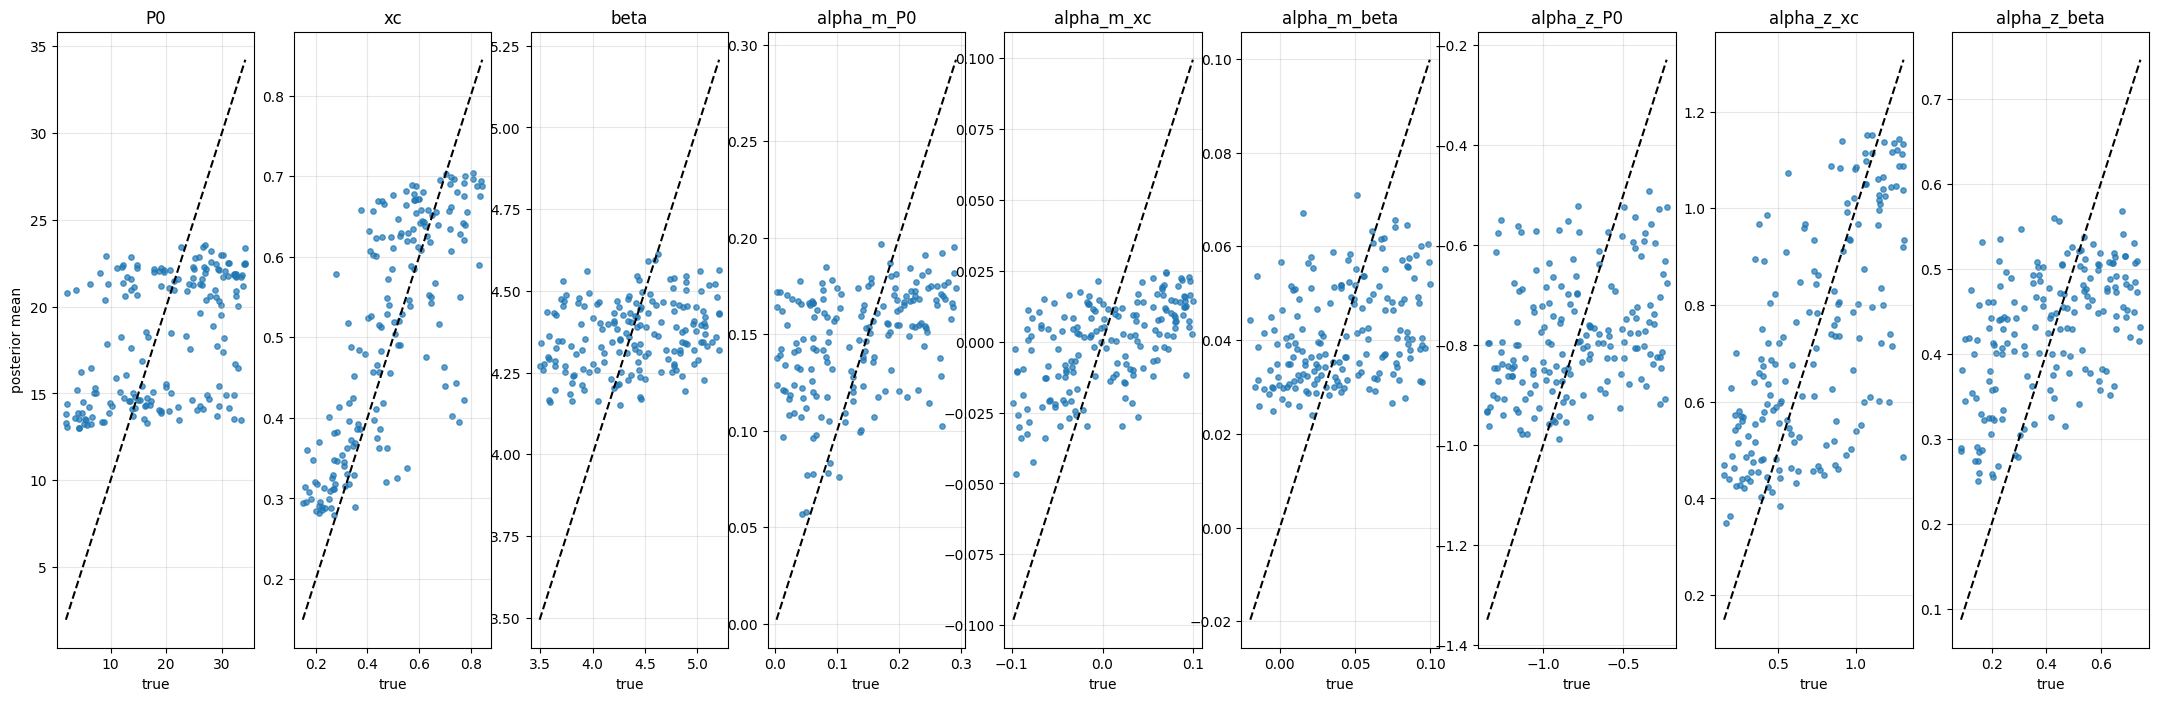

In [56]:
plot_recovery_scatter(
    validation_samples,
    split["theta_val"],
    labels=columns,
    savefig_bool = True,
    savefig_name = "posterior_mean_vs_true_4096.jpg"
)

# Posterior contraction on validation set

In [34]:
def posterior_contraction(
    posterior_samples,
    prior_min,
    prior_max,
    labels=None,
):
    samples = to_tensor(posterior_samples)
    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)

    prior_delta = prior_max - prior_min
    posterior_std = samples.std(dim=1)

    contraction = posterior_std / prior_delta

    n_params = samples.shape[-1]

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    rows = []

    for j, name in enumerate(labels):
        rows.append({
            "parameter": name,
            "mean std / prior_delta": contraction[:, j].mean().item(),
            "median std / prior_delta": contraction[:, j].median().item(),
            "min std / prior_delta": contraction[:, j].min().item(),
            "max std / prior_delta": contraction[:, j].max().item(),
        })

    return pd.DataFrame(rows)

In [35]:
contraction_df = posterior_contraction(
    validation_samples,
    prior_low_cpu,
    prior_high_cpu,
    labels=columns,
)

contraction_df

,parameter,mean std / prior_delta,median std / prior_delta,min std / prior_delta,max std / prior_delta
0,P0,0.204230,0.203879,0.174140,0.225761
1,xc,0.145053,0.144013,0.107261,0.204462
2,beta,0.223397,0.224340,0.185001,0.243294
3,alpha_m_P0,0.218626,0.221315,0.153156,0.243686
4,alpha_m_xc,0.221329,0.221606,0.182746,0.238470
5,alpha_m_beta,0.220266,0.222087,0.175080,0.240491
6,alpha_z_P0,0.214729,0.216572,0.171451,0.248315
7,alpha_z_xc,0.157727,0.161718,0.095802,0.190369
8,alpha_z_beta,0.204736,0.206445,0.153711,0.232581


# diagnostics vs training-set size

In [72]:
def to_tensor(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().float()
    return torch.as_tensor(x, dtype=torch.float32)


def make_fixed_train_val_split(theta, x, n_val=174, seed=0):
    """
    Creates one fixed validation set.
    The remaining simulations form the training pool.
    """
    theta = to_tensor(theta)
    x = to_tensor(x)

    n_total = theta.shape[0]

    rng = torch.Generator().manual_seed(seed)
    indices = torch.randperm(n_total, generator=rng)

    val_idx = indices[:n_val]
    train_pool_idx = indices[n_val:]

    return {
        "theta_train_pool": theta[train_pool_idx],
        "x_train_pool": x[train_pool_idx],
        "theta_val": theta[val_idx],
        "x_val": x[val_idx],
        "train_pool_idx": train_pool_idx,
        "val_idx": val_idx,
    }


def sample_posteriors(
    posterior,
    x_eval,
    num_posterior_samples=1000,
):
    """
    Returns posterior samples with shape:
    (n_eval, num_posterior_samples, n_params)
    """
    x_eval = to_tensor(x_eval)

    all_samples = []

    for i in range(x_eval.shape[0]):
        samples_i = posterior.sample(
            (num_posterior_samples,),
            x=x_eval[i],
            show_progress_bars=False,
        )
        all_samples.append(samples_i.detach().cpu())

    return torch.stack(all_samples, dim=0)

In [73]:
def compute_validation_metrics(
    posterior_samples,
    theta_true,
    prior_min,
    prior_max,
    labels=None,
    split_name="validation",
    n_train=None,
):
    """
    Computes the most useful SBI validation metrics per parameter.

    posterior_samples shape:
        (n_eval, n_posterior_samples, n_params)
    """

    samples = to_tensor(posterior_samples)
    theta_true = to_tensor(theta_true)

    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)
    prior_delta = prior_max - prior_min

    n_eval, n_post, n_params = samples.shape

    if labels is None:
        labels = [f"param_{i}" for i in range(n_params)]

    posterior_mean = samples.mean(dim=1)
    posterior_median = samples.median(dim=1).values
    posterior_std = samples.std(dim=1)

    error = posterior_mean - theta_true
    abs_error = torch.abs(error)

    eps = 1e-12
    z_score = error / (posterior_std + eps)

    rows = []

    for j, label in enumerate(labels):
        theta_j = theta_true[:, j]
        samples_j = samples[:, :, j]

        # 68% interval
        low_68 = torch.quantile(samples_j, 0.16, dim=1)
        high_68 = torch.quantile(samples_j, 0.84, dim=1)
        coverage_68 = ((theta_j >= low_68) & (theta_j <= high_68)).float().mean()

        # 90% interval
        low_90 = torch.quantile(samples_j, 0.05, dim=1)
        high_90 = torch.quantile(samples_j, 0.95, dim=1)
        coverage_90 = ((theta_j >= low_90) & (theta_j <= high_90)).float().mean()

        # 95% interval
        low_95 = torch.quantile(samples_j, 0.025, dim=1)
        high_95 = torch.quantile(samples_j, 0.975, dim=1)
        coverage_95 = ((theta_j >= low_95) & (theta_j <= high_95)).float().mean()

        rows.append({
            "n_train": n_train,
            "split": split_name,
            "parameter": label,

            "bias / prior_delta": (error[:, j] / prior_delta[j]).mean().item(),
            "abs_bias / prior_delta": torch.abs((error[:, j] / prior_delta[j]).mean()).item(),

            "mean_abs_error / prior_delta": (abs_error[:, j] / prior_delta[j]).mean().item(),

            "mean_posterior_std / prior_delta": (posterior_std[:, j] / prior_delta[j]).mean().item(),
            "median_posterior_std / prior_delta": (posterior_std[:, j] / prior_delta[j]).median().item(),

            "rms_z_score": torch.sqrt(torch.mean(z_score[:, j] ** 2)).item(),
            "mean_abs_z_score": torch.abs(z_score[:, j]).mean().item(),

            "coverage_68": coverage_68.item(),
            "coverage_90": coverage_90.item(),
            "coverage_95": coverage_95.item(),

            "coverage_68_error": coverage_68.item() - 0.68,
            "coverage_90_error": coverage_90.item() - 0.90,
            "coverage_95_error": coverage_95.item() - 0.95,
        })

    return pd.DataFrame(rows)

In [74]:
def run_training_size_diagnostics(
    theta,
    x,
    prior_min,
    prior_max,
    train_sizes,
    n_val=174,
    labels=None,
    seed=0,
    num_posterior_samples=1000,
    evaluate_training_set=True,
    max_train_eval=100,
    train_kwargs=None,
):
    """
    Trains separate NPE models with different training-set sizes
    and evaluates metrics on a fixed validation set.

    Optionally also evaluates on part of the training set to diagnose overfitting.
    """

    theta = to_tensor(theta)
    x = to_tensor(x)

    prior_min = to_tensor(prior_min).reshape(-1)
    prior_max = to_tensor(prior_max).reshape(-1)

    prior = BoxUniform(
        low=prior_min,
        high=prior_max,
    )

    split = make_fixed_train_val_split(
        theta,
        x,
        n_val=n_val,
        seed=seed,
    )

    theta_train_pool = split["theta_train_pool"]
    x_train_pool = split["x_train_pool"]

    theta_val = split["theta_val"]
    x_val = split["x_val"]

    if labels is None:
        labels = [f"param_{i}" for i in range(theta.shape[1])]

    all_metrics = []
    posteriors = {}

    if train_kwargs is None:
        train_kwargs = {}

    for n_train in train_sizes:
        print(f"\nTraining NPE with n_train = {n_train}")

        if n_train > theta_train_pool.shape[0]:
            raise ValueError(
                f"n_train={n_train} is larger than available training pool "
                f"{theta_train_pool.shape[0]}"
            )

        theta_train = theta_train_pool[:n_train]
        x_train = x_train_pool[:n_train]

        inference = NPE(prior=prior)

        density_estimator = inference.append_simulations(
            theta_train,
            x_train,
        ).train(**train_kwargs)

        posterior = inference.build_posterior(density_estimator)
        posteriors[n_train] = posterior

        # validation metrics
        print("  Sampling validation posteriors...")
        val_samples = sample_posteriors(
            posterior,
            x_val,
            num_posterior_samples=num_posterior_samples,
        )

        val_metrics = compute_validation_metrics(
            posterior_samples=val_samples,
            theta_true=theta_val,
            prior_min=prior_min,
            prior_max=prior_max,
            labels=labels,
            split_name="validation",
            n_train=n_train,
        )

        all_metrics.append(val_metrics)

        # optional training-set metrics
        if evaluate_training_set:
            n_train_eval = min(max_train_eval, n_train)

            print(f"  Sampling training posteriors for {n_train_eval} examples...")

            train_samples = sample_posteriors(
                posterior,
                x_train[:n_train_eval],
                num_posterior_samples=num_posterior_samples,
            )

            train_metrics = compute_validation_metrics(
                posterior_samples=train_samples,
                theta_true=theta_train[:n_train_eval],
                prior_min=prior_min,
                prior_max=prior_max,
                labels=labels,
                split_name="training",
                n_train=n_train,
            )

            all_metrics.append(train_metrics)

    metrics_df = pd.concat(all_metrics, ignore_index=True)

    return metrics_df, posteriors, split

In [82]:
train_sizes = [50, 100, 300, 500, 700, 850]

metrics_df, posteriors, split = run_training_size_diagnostics(
    theta=theta,
    x=x_mean,
    prior_min=prior_low_cpu,
    prior_max=prior_high_cpu,
    train_sizes=train_sizes,
    n_val=174,
    labels=columns,
    seed=1,
    num_posterior_samples=1000,
    evaluate_training_set=True,
    max_train_eval=100,
)

if SAVE_NOTEBOOK_TRAINING_OUTPUTS:
    diagnostics_dir = NOTEBOOK_SBI_OUTPUT_DIR / "training_size_diagnostics"
    diagnostics_dir.mkdir(parents=True, exist_ok=True)
    metrics_df.to_csv(diagnostics_dir / "training_size_metrics.csv", index=False)
    save_pickle(diagnostics_dir / "training_size_posteriors.pkl", posteriors)
    np.savez_compressed(
        diagnostics_dir / "training_size_split.npz",
        val_idx=split["val_idx"].detach().cpu().numpy(),
        train_pool_idx=split["train_pool_idx"].detach().cpu().numpy(),
    )
    write_json(
        diagnostics_dir / "training_size_summary.json",
        {
            "dataset_path": str(DATASET_PATH),
            "train_sizes": [int(size) for size in train_sizes],
            "n_val": 174,
            "num_posterior_samples": 1000,
            "columns": list(columns),
        },
    )
    print(f"Saved training-size diagnostics to {diagnostics_dir}")


Training NPE with n_train = 50
 Neural network successfully converged after 134 epochs.  Sampling validation posteriors...
  Sampling training posteriors for 50 examples...

Training NPE with n_train = 100
 Neural network successfully converged after 239 epochs.  Sampling validation posteriors...
  Sampling training posteriors for 100 examples...

Training NPE with n_train = 300
 Neural network successfully converged after 245 epochs.  Sampling validation posteriors...
  Sampling training posteriors for 100 examples...

Training NPE with n_train = 500
 Neural network successfully converged after 165 epochs.  Sampling validation posteriors...
  Sampling training posteriors for 100 examples...

Training NPE with n_train = 700
 Neural network successfully converged after 195 epochs.  Sampling validation posteriors...
  Sampling training posteriors for 100 examples...

Training NPE with n_train = 850
 Neural network successfully converged after 161 epochs.  Sampling validation posteriors.

In [83]:
metrics_df

,n_train,split,parameter,bias / prior_delta,abs_bias / prior_delta,mean_abs_error / prior_delta,mean_posterior_std / prior_delta,median_posterior_std / prior_delta,rms_z_score,mean_abs_z_score,coverage_68,coverage_90,coverage_95,coverage_68_error,coverage_90_error,coverage_95_error
0,50,validation,P0,0.028256,0.028256,0.227200,0.256054,0.255681,1.028903,0.887485,0.620690,0.902299,0.959770,-0.059310,0.002299,0.009770
1,50,validation,xc,0.066318,0.066318,0.204450,0.203797,0.208661,1.154982,0.999290,0.505747,0.816092,0.896552,-0.174253,-0.083908,-0.053448
2,50,validation,beta,0.039745,0.039745,0.265721,0.251156,0.251335,1.196653,1.058754,0.482759,0.821839,0.890805,-0.197241,-0.078161,-0.059195
3,50,validation,alpha_m_P0,-0.006897,0.006897,0.244749,0.233006,0.230504,1.224469,1.051071,0.494253,0.810345,0.885057,-0.185747,-0.089655,-0.064943
4,50,validation,alpha_m_xc,-0.023326,0.023326,0.236655,0.232695,0.231100,1.208129,1.023299,0.551724,0.798851,0.867816,-0.128276,-0.101149,-0.082184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,850,training,alpha_m_xc,0.013937,0.013937,0.213618,0.213657,0.215306,1.171299,1.000074,0.560000,0.820000,0.860000,-0.120000,-0.080000,-0.090000
104,850,training,alpha_m_beta,0.043547,0.043547,0.229722,0.225254,0.226215,1.199049,1.016515,0.510000,0.770000,0.850000,-0.170000,-0.130000,-0.100000
105,850,training,alpha_z_P0,-0.007965,0.007965,0.240943,0.221361,0.221776,1.282902,1.091818,0.480000,0.720000,0.870000,-0.200000,-0.180000,-0.080000
106,850,training,alpha_z_xc,-0.027630,0.027630,0.188402,0.187434,0.190183,1.199068,1.007430,0.530000,0.800000,0.890000,-0.150000,-0.100000,-0.060000


In [84]:
def plot_aggregate_metrics_vs_training_size(metrics_df):
    metric_names = [
        "mean_abs_error / prior_delta",
        "abs_bias / prior_delta",
        "mean_posterior_std / prior_delta",
        "rms_z_score",
        "coverage_68",
        "coverage_90",
    ]

    for metric in metric_names:
        plt.figure(figsize=(7, 5))

        for split_name in metrics_df["split"].unique():
            d = metrics_df[metrics_df["split"] == split_name]

            agg = (
                d.groupby("n_train")[metric]
                .mean()
                .reset_index()
                .sort_values("n_train")
            )

            plt.plot(
                agg["n_train"],
                agg[metric],
                marker="o",
                label=split_name,
            )

        if metric == "coverage_68":
            plt.axhline(0.68, ls="--", color="black", label="ideal 0.68")
        if metric == "coverage_90":
            plt.axhline(0.90, ls="--", color="black", label="ideal 0.90")
        if metric == "rms_z_score":
            plt.axhline(1.0, ls="--", color="black", label="ideal 1")

        plt.xscale("log")
        plt.xlabel("Number of training simulations")
        plt.ylabel(metric)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

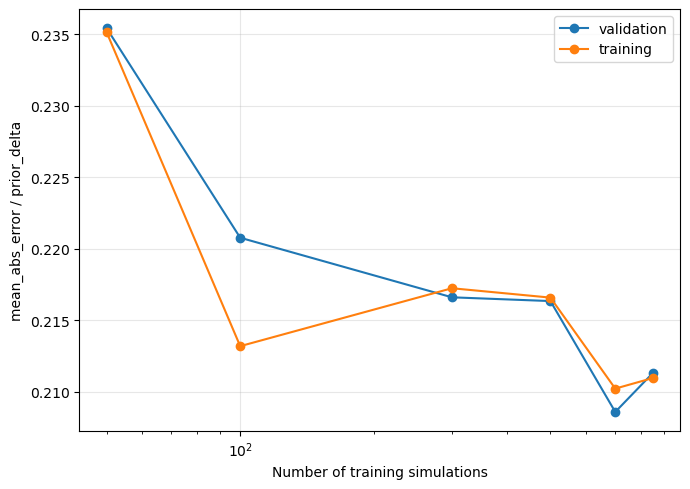

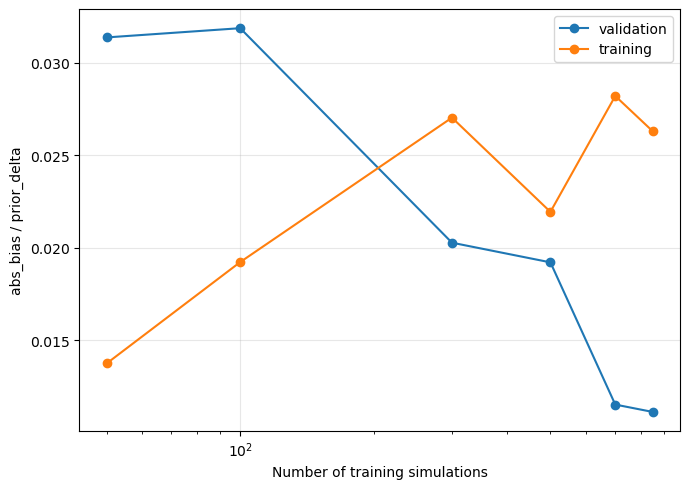

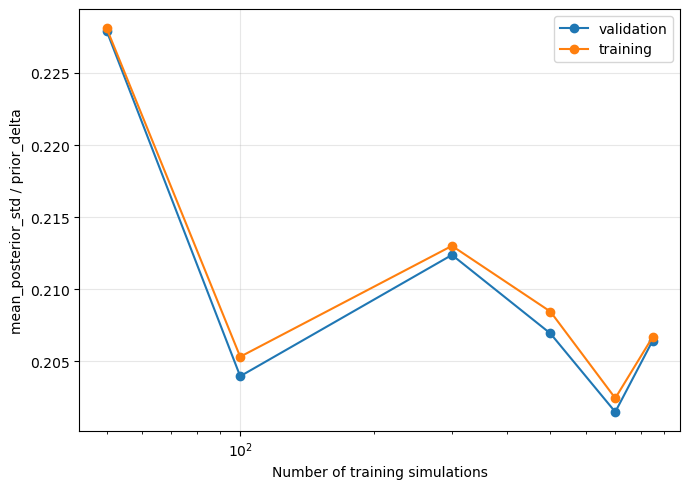

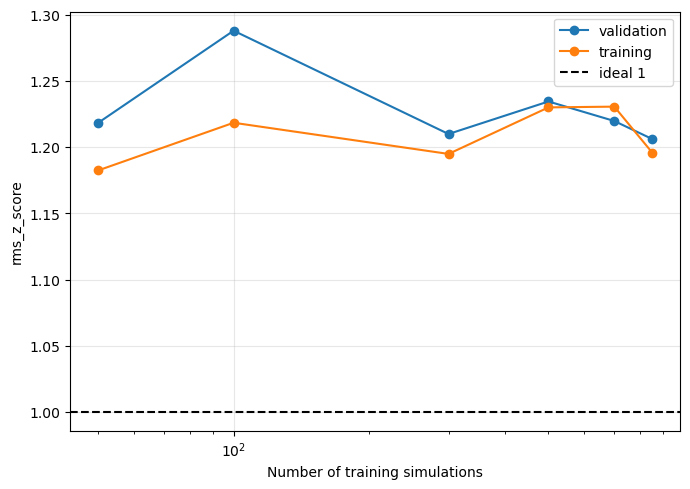

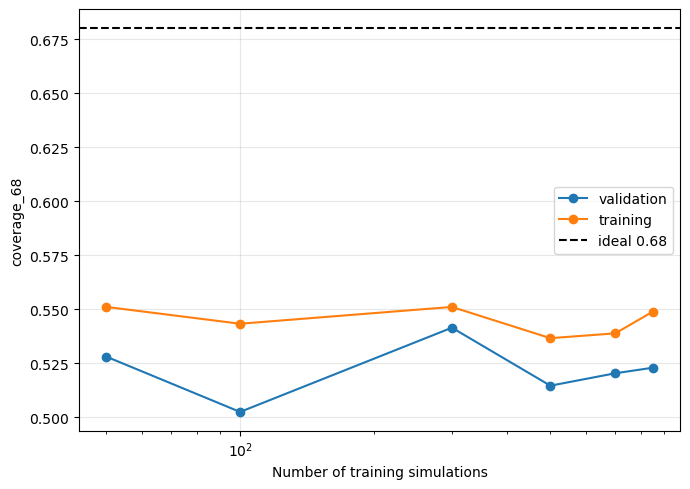

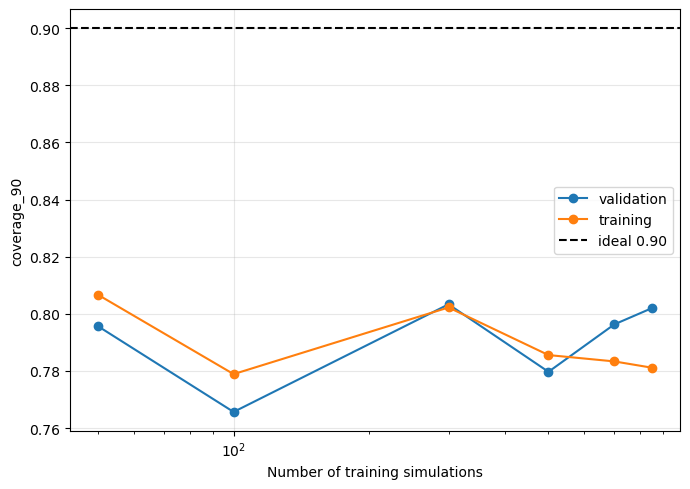

In [85]:
plot_aggregate_metrics_vs_training_size(metrics_df)

In [86]:
def plot_parameter_metric_vs_training_size(
    metrics_df,
    metric,
    split_name="validation",
):
    d = metrics_df[metrics_df["split"] == split_name].copy()

    params = d["parameter"].unique()

    plt.figure(figsize=(9, 6))

    for p in params:
        dp = d[d["parameter"] == p].sort_values("n_train")

        plt.plot(
            dp["n_train"],
            dp[metric],
            marker="o",
            label=p,
        )

    if metric == "coverage_68":
        plt.axhline(0.68, ls="--", color="black", label="ideal 0.68")
    if metric == "coverage_90":
        plt.axhline(0.90, ls="--", color="black", label="ideal 0.90")
    if metric == "rms_z_score":
        plt.axhline(1.0, ls="--", color="black", label="ideal 1")

    plt.xscale("log")
    plt.xlabel("Number of training simulations")
    plt.ylabel(metric)
    plt.title(f"{metric} on {split_name} set")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

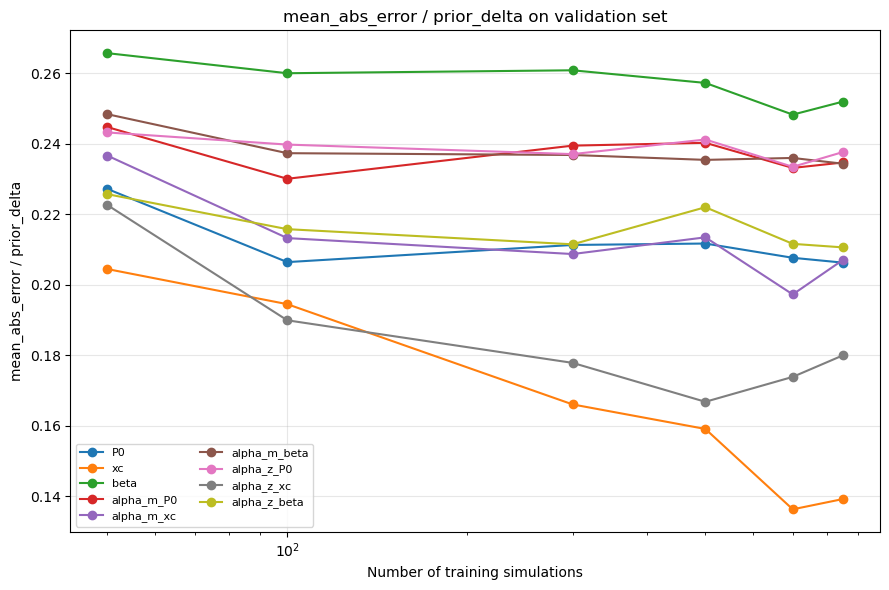

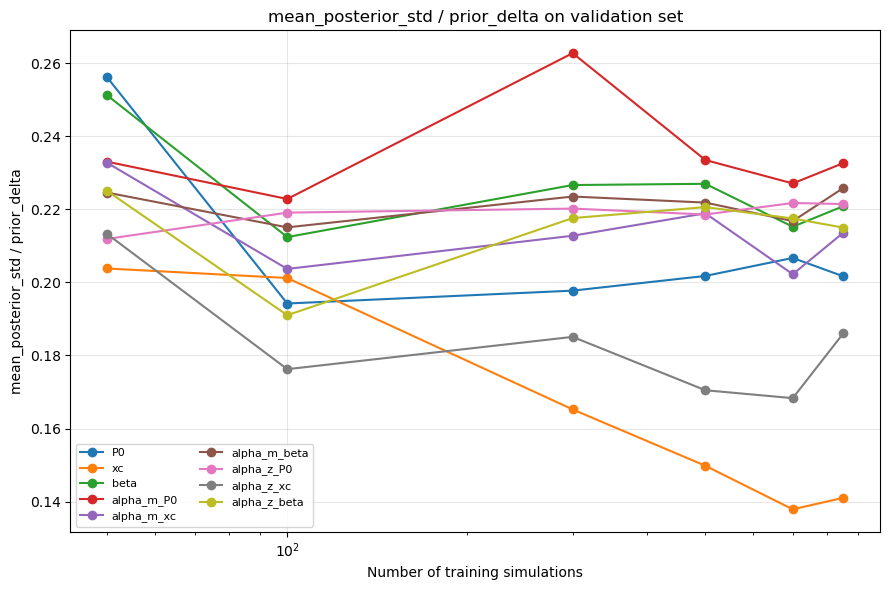

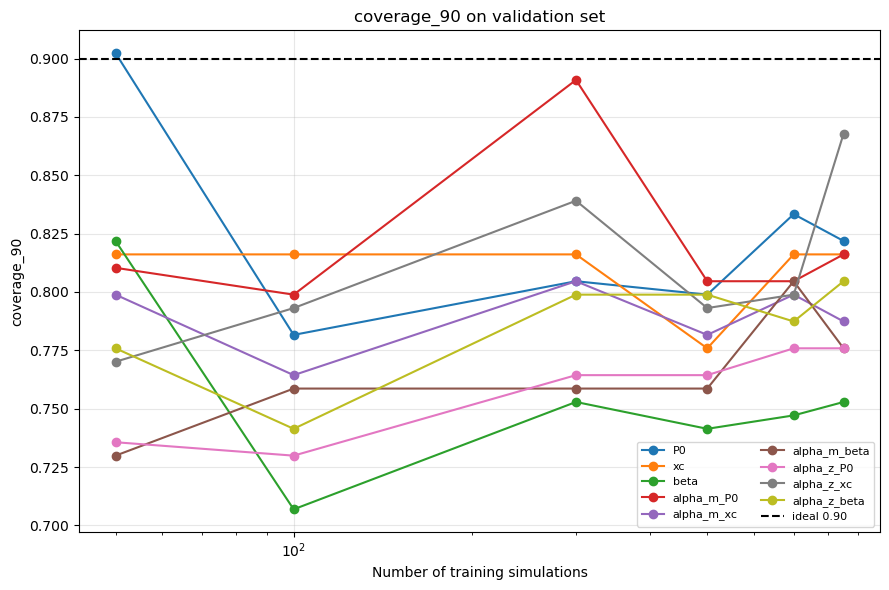

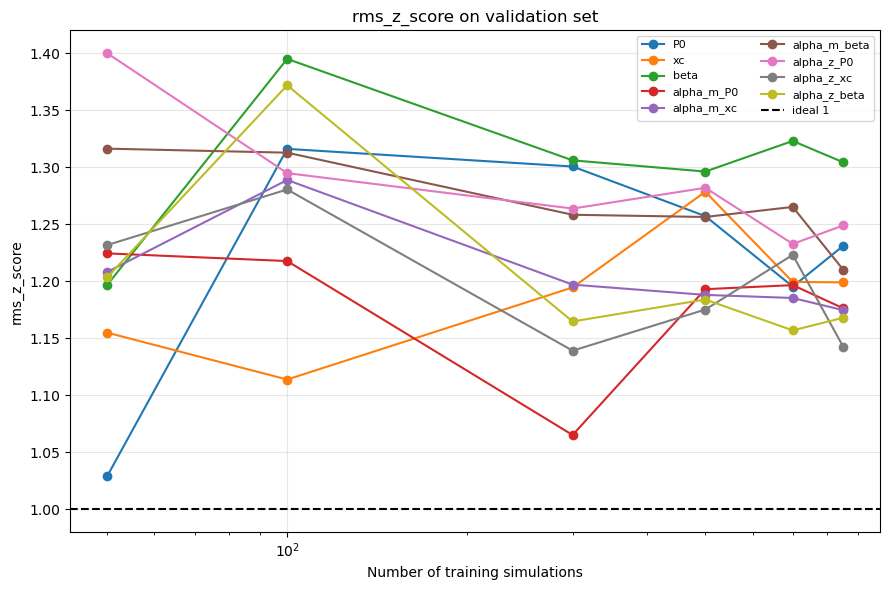

In [87]:
plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="mean_abs_error / prior_delta",
    split_name="validation",
)

plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="mean_posterior_std / prior_delta",
    split_name="validation",
)

plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="coverage_90",
    split_name="validation",
)

plot_parameter_metric_vs_training_size(
    metrics_df,
    metric="rms_z_score",
    split_name="validation",
)